In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.constants import G, M_sun
from astropy import units as u
import emcee
from scipy.optimize import fsolve

__Graph the RVs and Days__

In [137]:
def plotparams(ax, labelsize=15):
    '''
    Basic plot params

    :param ax: axes to modify

    :type ax: matplotlib axes object

    :returns: modified matplotlib axes object
    '''
    ax.minorticks_on()
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(direction='in', which='both', labelsize=labelsize)
    ax.tick_params('both', length=8, width=1.8, which='major')
    ax.tick_params('both', length=4, width=1, which='minor')
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.5)
    return ax

Text(0, 0.5, 'Radial Velocity [km/s]')

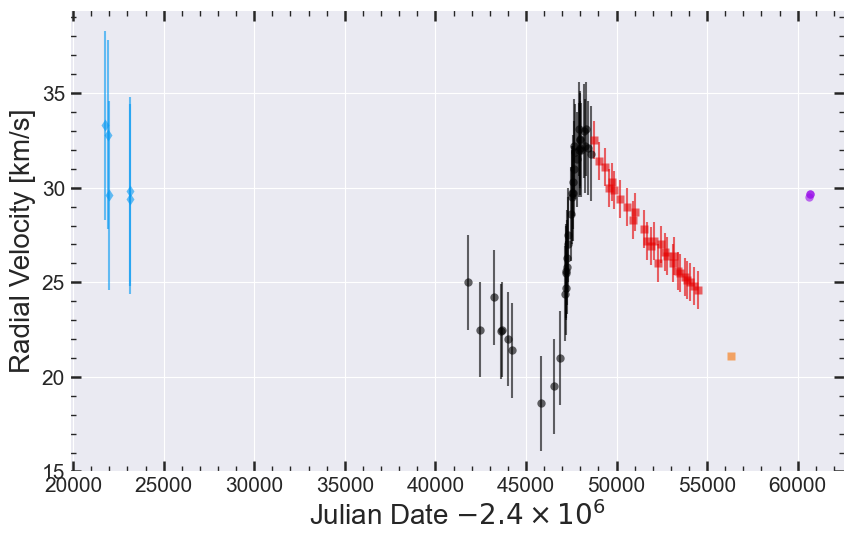

In [138]:
df = pd.read_csv('HD104438_RVs.csv')

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax = plotparams(ax)

instrument_weights = {
    1.0: 'CORAVEL',
    0.25: 'Cambridge Spectrometer',
    0.025: 'Mount Wilson 60inch'
}

rv_err_weights = {
    1.0: 1,
    0.25: 2.5,
    0.025: 5.0
}

df['Instrument'] = df.Weight.map(instrument_weights)
df['RV_err'] = df.Weight.map(rv_err_weights)

df_apogee = pd.DataFrame({'JD':[2456337.762], 'RV': [21.105],
                          'RV_err':[0.02474], 'Instrument':['APOGEE'], 'Weight':[1.0]})

df_apf = pd.DataFrame({'JD':[2460648.893223666, 2460663.8506141417, 2460653.898714318],
                       'RV':[29.51, 29.68, 29.65]})
df_apf['Instrument'] = 'APF'
df_apf['Weight'] = 1.0

df = pd.concat([df, df_apogee, df_apf])

instrument_list = df.Instrument.value_counts().index
markers = ['o', 's', 'd', 'o', 's']
colors = ['black', 'xkcd:red', 'xkcd:azure', 'xkcd:violet', 'xkcd:orange']

for instrument, marker, color in zip(instrument_list, markers, colors):
    ax.errorbar(df[df.Instrument == instrument].JD - 2.4e6, df[df.Instrument == instrument].RV, 
                yerr=df[df.Instrument == instrument].RV_err, marker=marker, color=color, ls='',
                markeredgecolor='none', alpha=0.6)

ax.set_xlabel(r'Julian Date $ - 2.4\times10^6$', fontsize=20)
ax.set_ylabel('Radial Velocity [km/s]', fontsize=20)

__First, use MCMC methods to constrain the RV orbit__

"For each target, we fit the archival RVs using a Keplerian
orbit model of the form 

RV(𝑡) = 𝛾 + 𝐾 [(𝜔 + 𝑓 ) + 𝑒 cos𝜔] 

where 𝛾 is the center-of-mass velocity, 𝐾 is the radial velocity
semiamplitudes, 𝑓 is the true anomaly, and 𝜔 is the argument
of periastron. The true anomaly, 𝑓 , is defined based on the
eccentric anomaly, 𝐸, and the eccentricity, 𝑒 by

cos 𝑓 =
cos 𝐸 − 𝑒
1 − 𝑒 cos �

and the eccentric anomaly is
𝐸 − 𝑒 sin 𝐸 =
2𝜋(𝑡 − 𝑇0)
𝑃
(4)
where 𝑃 is the period and 𝑇0 is the time of periastron."

--> (https://arxiv.org/pdf/2410.19050) page 6

In [190]:
def solve_kepler(M, e, tol=1e-10, max_iter=100):
    M = np.mod(M, 2*np.pi)
    E = M + 0.85 * e * np.sign(np.sin(M))  # Smarter initial guess

    for _ in range(max_iter):
        f = E - e * np.sin(E) - M
        f_prime = 1 - e * np.cos(E)
        delta = f / f_prime
        E_new = E - delta

        if np.all(np.abs(delta) < tol):
            return E_new

        E = E_new

    raise RuntimeError("Kepler solver failed to converge.")


In [211]:
def keplerian_model(t, P, K, e, gamma, omega_deg, T0):
    """
    Keplerian radial velocity model.
    omega_deg: argument of periastron in degrees.
    """
    omega = np.radians(omega_deg)

    M = 2 * np.pi * (t - T0) / P
    M = np.mod(M, 2 * np.pi)

    E = solve_kepler(M, e)
    nu = 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E / 2))

    rv = gamma + K * (np.cos(omega + nu) + e * np.cos(omega))
    return rv


In [212]:
# Define terms
t = df.iloc[:, 0].values # JD
rv_obs = df.iloc[:, 1].values
rv_err = df.iloc[:, 2].values

# Fixed parameters
P = 13000
K = 6.7
offset = 0 #1.4 I need this to be if the weight is 0, then 1.4 offset, and 0.25 ... 0.025

In [213]:
# Make sure no zeros/negatives
rv_err[rv_err <= 0] = np.min(rv_err[rv_err > 0]) * 0.1
if np.any(np.isnan(rv_err)):
    raise ValueError("RV error contains NaNs!")

In [214]:
# Priors
params = np.array([0.58, 24.2, -80.0, 2401400])       # Time of periastron [JD = 1400 + 2.4e6]])

In [215]:
# Define functions
def log_prior(params): #uniform prior
    e, gamma, omega, T0 = params
    if not (0.0 <= e <= 0.99): return -np.inf
    if not (10 <= gamma <= 50): return -np.inf
    if not (-180 <= omega <= 180): return -np.inf
    if not (2000000 <= T0 <= 3000000): return -np.inf
    return 0.0


    
def log_likelihood(params, t, P, K, rv_obs, rv_err):
    e, gamma, omega, T0 = params
    model = keplerian_model(t, P, K, e, gamma, omega, T0)
    if np.any(np.isnan(model)):
        return -np.inf
    if np.any(np.isnan(model)) or np.any(~np.isfinite(model)):
        return -np.inf
    return -0.5 * np.sum((rv_obs - model)**2 / rv_err + np.log(rv_err))
    #return -0.5 * np.sum(((rv_obs - model) / rv_err)**2 + np.log(2 * np.pi * rv_err**2))


def log_probability(params, t, P, K, rv_obs, rv_err):
    lp =log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return  log_likelihood(params, t, P, K, rv_obs, rv_err) + lp


In [216]:
# Now set up the MCMC chain

ndim = len(params)
nwalkers = 2 * ndim
scale = [0.01, .03, 2, 50]  # step size for initial scatter

np.random.seed(163)
pos = params + scale * np.random.randn(nwalkers, ndim)

In [217]:
# Enforce bounds to keep walkers in reasonable regions
for p in pos:
    p[0] = np.clip(p[0], 0.1, 0.8)     # e
    p[1] = np.clip(p[1], 15, 40)          # gamma
    p[2] = np.clip(p[2], -180, 180)      # omega (deg)
    p[3] = np.clip(p[3], 2000000, 2800000)     # T0

In [218]:
# Now run the MCMC
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(t, P, K, rv_obs, rv_err)
)

print("Running MCMC...")
sampler.run_mcmc(pos, 50000, progress=True)
print("MCMC complete.")

Running MCMC...


100%|███████████████████████████████████| 50000/50000 [00:22<00:00, 2226.86it/s]

MCMC complete.


In [219]:
samples = sampler.get_chain(discard=0, flat=True)

# Parameter names for printing
param_names = ["e","gamma", "omega (deg)", "T0"]

# Print median and ±1σ for each parameter
for i in range(samples.shape[1]):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{param_names[i]} = {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")


e = 0.9608 (+0.0005, -0.9605)
gamma = 27.2542 (+0.0446, -0.2583)
omega (deg) = -179.9472 (+335.1481, -0.0445)
T0 = 2394500.4671 (+10417.8876, -0.2595)


In [220]:
# Flatten chain after burn-in and thinning
flat_samples = sampler.get_chain(discard=10000, flat=True)

# Parameter names for printing
param_names = ["e","gamma", "omega (deg)", "T0"]

# Print median and ±1σ for each parameter
for i in range(flat_samples.shape[1]):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{param_names[i]} = {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")


e = 0.9608 (+0.0004, -0.9605)
gamma = 27.2570 (+0.0342, -0.2501)
omega (deg) = -179.9690 (+324.3321, -0.0247)
T0 = 2394500.3766 (+10082.7653, -0.1946)


In [221]:
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))


Mean acceptance fraction: 0.3097425


In [222]:
mcmc = np.percentile(flat_samples[:, 2], [16, 50, 84])
q = np.diff(mcmc)
print(f"{param_names[2]} = {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")

omega (deg) = -179.9690 (+324.3321, -0.0247)


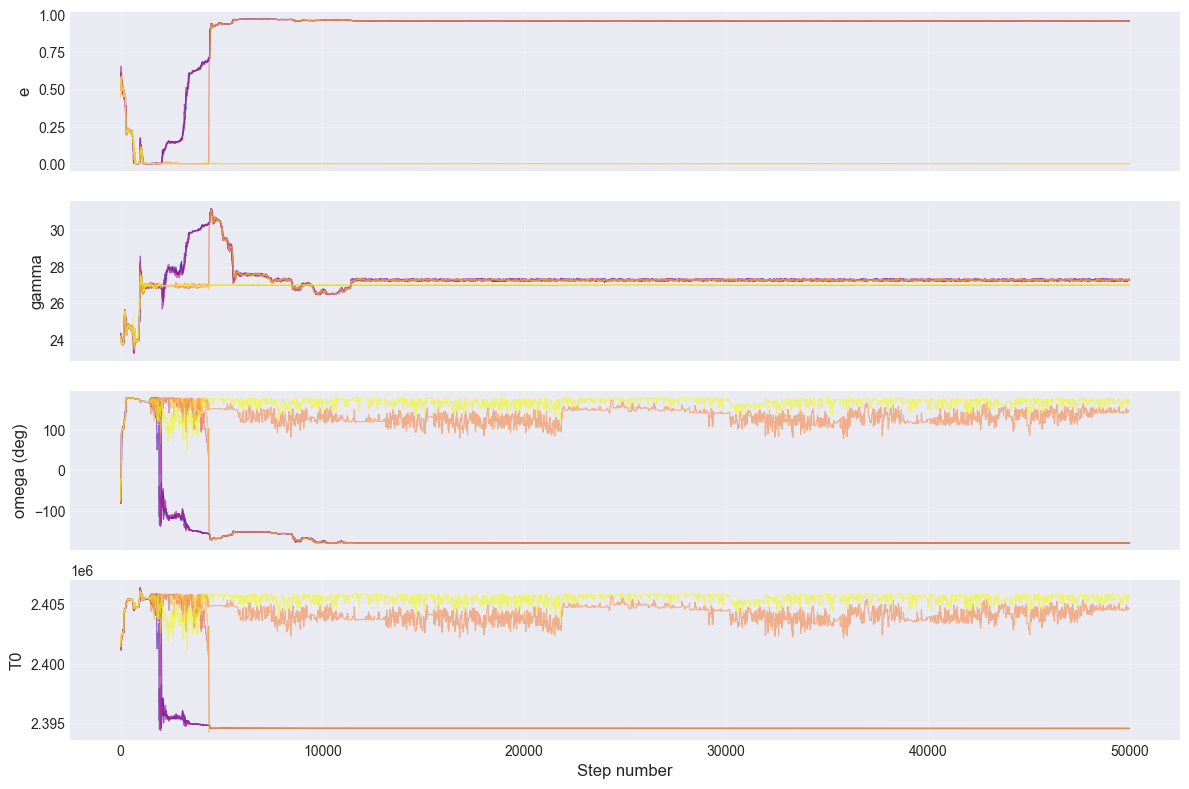

In [223]:
import matplotlib.pyplot as plt
import matplotlib as mpl

samples = sampler.get_chain()  # shape: (n_steps, n_walkers, n_params)
param_names = ["e", "gamma", "omega (deg)", "T0"]

# Optional: Use a darker style
plt.style.use("seaborn-v0_8-darkgrid")

fig, axes = plt.subplots(len(param_names), figsize=(12, 8), sharex=True)

n_steps, n_walkers, _ = samples.shape
colors = mpl.cm.plasma(np.linspace(0, 1, n_walkers))  # Use colormap for visual separation

for i, ax in enumerate(axes):
    for j in range(n_walkers):
        ax.plot(samples[:, j, i], color=colors[j], alpha=0.6, lw=0.8)
    ax.set_ylabel(param_names[i], fontsize=12)
    ax.tick_params(labelsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Step number", fontsize=12)
plt.tight_layout()
plt.show()


In [224]:
# Best-fit parameters = median of the posterior
best_fit = np.median(flat_samples, axis=0)
e_best, gamma_best, omega_best, T0_best = best_fit

rv_model = keplerian_model(t, P, K, e_best, gamma_best, omega_best, T0_best)

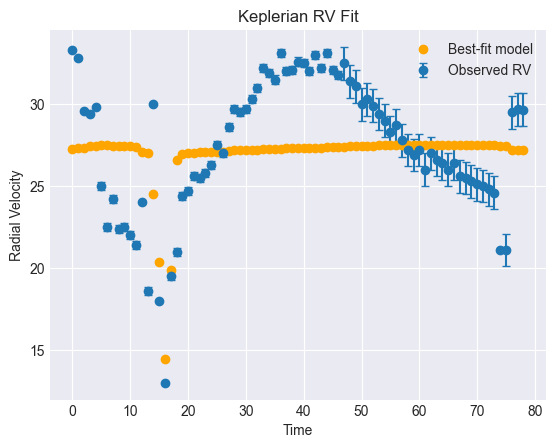

In [225]:
import matplotlib.pyplot as plt

plt.errorbar(range(len(t)), rv_obs, yerr=rv_err, fmt='o', label='Observed RV', capsize=3)
plt.plot(range(len(t)), rv_model, label='Best-fit model',  color='orange', marker='o',linestyle='none')

#t_grid = np.linspace(2.420, 2.460, 1000)
#rv_grid = keplerian_model(t_grid, P, K, e_best, gamma_best, omega_best, T0_best, offset)
#plt.plot(t_grid, rv_grid)

plt.xlabel("Time")
plt.ylabel("Radial Velocity")
plt.legend()
plt.title("Keplerian RV Fit")
plt.show()

In [226]:
# ---------------------------------------------------------------
# χ² and reduced-χ² for the best-fit model (uses gamma_best, etc.)
# ---------------------------------------------------------------
e_best, gamma_best, omega_best, T0_best = best_fit           # already defined
rv_model_best = keplerian_model(t, P, K,
                                e_best, gamma_best,
                                omega_best, T0_best
                            )

# χ² = Σ[(obs − model)/σ]²
chi2 = np.sum(((rv_obs - rv_model_best)/rv_err)**2)

# reduced χ²  (ν = N − k,  k = # free parameters = 4 here)
nu = len(rv_obs) - 4
chi2_red = chi2 / nu

print(f"χ² (best-fit)       : {chi2:.3f}")
print(f"reduced χ² (ν={nu}) : {chi2_red:.3f}")

χ² (best-fit)       : 7965117.354
reduced χ² (ν=75) : 106201.565


Print an array of walkers

In [227]:
print(f"Period P = {P}")
print(f"Time span = {t.max() - t.min()} days")
print(f"K = {K}")
print(f"e = {e_best}")
print(f"omega = {omega_best} (degrees)")
print(f"T0 = {T0_best}")
#print("Sample M:", (2 * np.pi * (t - T0) / P)[:5])


Period P = 13000
Time span = 38895.690614141524 days
K = 6.7
e = 0.9608276220743037
omega = -179.96904411595318 (degrees)
T0 = 2394500.3766486403


Running MCMC...


100%|████████████████████████████████████| 10000/10000 [00:18<00:00, 532.64it/s]


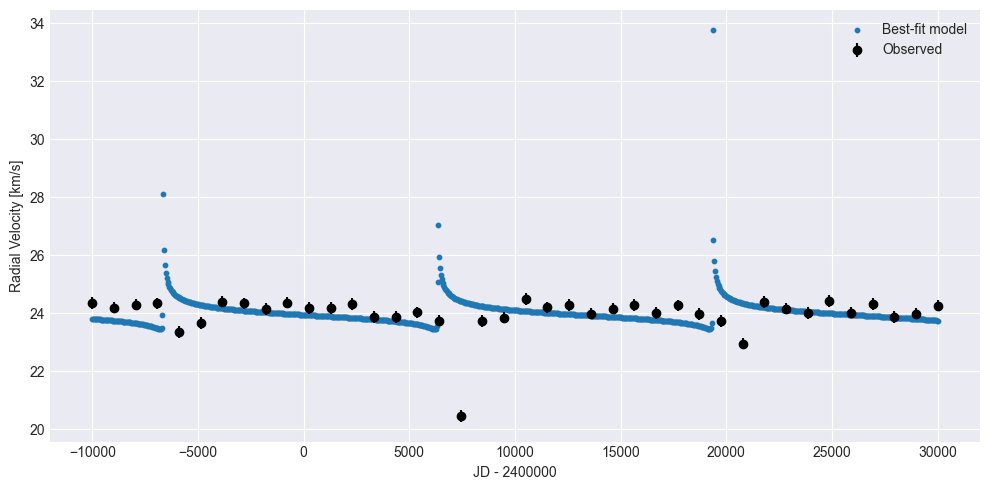

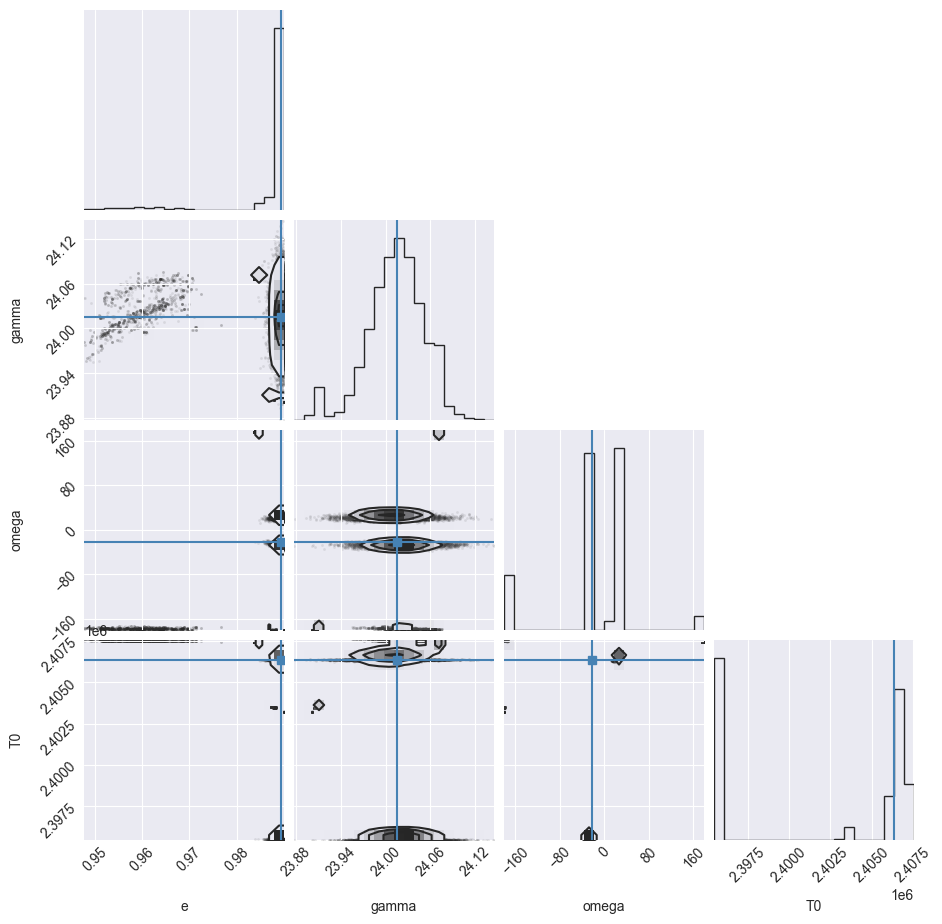

In [247]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
def solve_kepler(M, e, tol=1e-10, max_iter=100):
    """
    Robust Kepler solver that handles high eccentricity and small M.
    Solves M = E - e*sin(E) using Newton-Raphson with better initial guess.
    """
    M = np.mod(M, 2*np.pi)
    E = np.where(e < 0.8, M, np.pi * np.ones_like(M))  # Better guess for high e

    for i in range(max_iter):
        f = E - e * np.sin(E) - M
        f_prime = 1 - e * np.cos(E)
        delta = f / f_prime
        E -= delta
        if np.all(np.abs(delta) < tol):
            return E

    # If we fail to converge, raise error
    raise RuntimeError("Kepler solver failed to converge.")


# === Keplerian Model ===
def keplerian_model(t, P, K, e, gamma, omega_deg, T0):
    omega = np.radians(omega_deg)
    M = 2 * np.pi * (t - T0) / P
    E = solve_kepler(M, e)
    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                        np.sqrt(1 - e) * np.cos(E / 2))
    rv = gamma + K * (np.cos(omega + nu) + e * np.cos(omega))
    return rv

# === Load your data (replace with your actual DataFrame or file) ===
# Example simulation if you don't have data
np.random.seed(42)
t = np.linspace(2390000, 2430000, 40)
P = 13000
K = 6.7
true_params = [0.96, 24.0, -179.9, 2394500.4]
rv_true = keplerian_model(t, P, K, *true_params)
rv_err = np.full_like(rv_true, 0.2)  # constant error
rv_obs = rv_true + np.random.normal(0, rv_err)

# === Log Prior ===
def log_prior(theta):
    e, gamma, omega, T0 = theta
    if not (0.1 <= e <= 0.99):
        return -np.inf
    if not (0 <= gamma <= 40):
        return -np.inf
    if not (-180 <= omega <= 180):
        return -np.inf
    if not (2000000 <= T0 <= 2800000):
        return -np.inf
    return 0.0

# === Log Likelihood ===
def log_likelihood(theta, t, rv_obs, rv_err):
    e, gamma, omega, T0 = theta
    model = keplerian_model(t, P, K, e, gamma, omega, T0)
    return -0.5 * np.sum(((rv_obs - model) / rv_err)**2 + np.log(2 * np.pi * rv_err**2))

# === Log Probability ===
def log_probability(theta, t, rv_obs, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, rv_obs, rv_err)

# === Initialize Walkers ===
ndim = 4
nwalkers = 32
initial = np.array([0.58, 24.0, -80.0, 2401400])
spread = [0.01, 0.5, 5.0, 100.0]
pos = initial + spread * np.random.randn(nwalkers, ndim)

# === Run MCMC ===
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, rv_obs, rv_err))
print("Running MCMC...")
sampler.run_mcmc(pos, 10000, progress=True)

# === Analyze Results ===
samples = sampler.get_chain(discard=2000, thin=15, flat=True)
best_fit = np.median(samples, axis=0)

# Plot RV Curve as data points for both observed and model
t_fine = np.linspace(min(t), max(t), 1000)
rv_model = keplerian_model(t_fine, P, K, *best_fit)

plt.figure(figsize=(10, 5))

# Observed data as points with error bars
plt.errorbar(t - 2.4e6, rv_obs, yerr=rv_err, fmt='o', label='Observed', color='black')

# Best-fit model as points
plt.scatter(t_fine - 2.4e6, rv_model, label='Best-fit model', color='tab:blue', s=10)

plt.xlabel("JD - 2400000")
plt.ylabel("Radial Velocity [km/s]")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# === Optional: Corner Plot ===
try:
    import corner
    labels = ['e', 'gamma', 'omega', 'T0']
    fig = corner.corner(samples, labels=labels, truths=best_fit)
    plt.show()
except ImportError:
    print("Install `corner` for posterior plots: pip install corner")


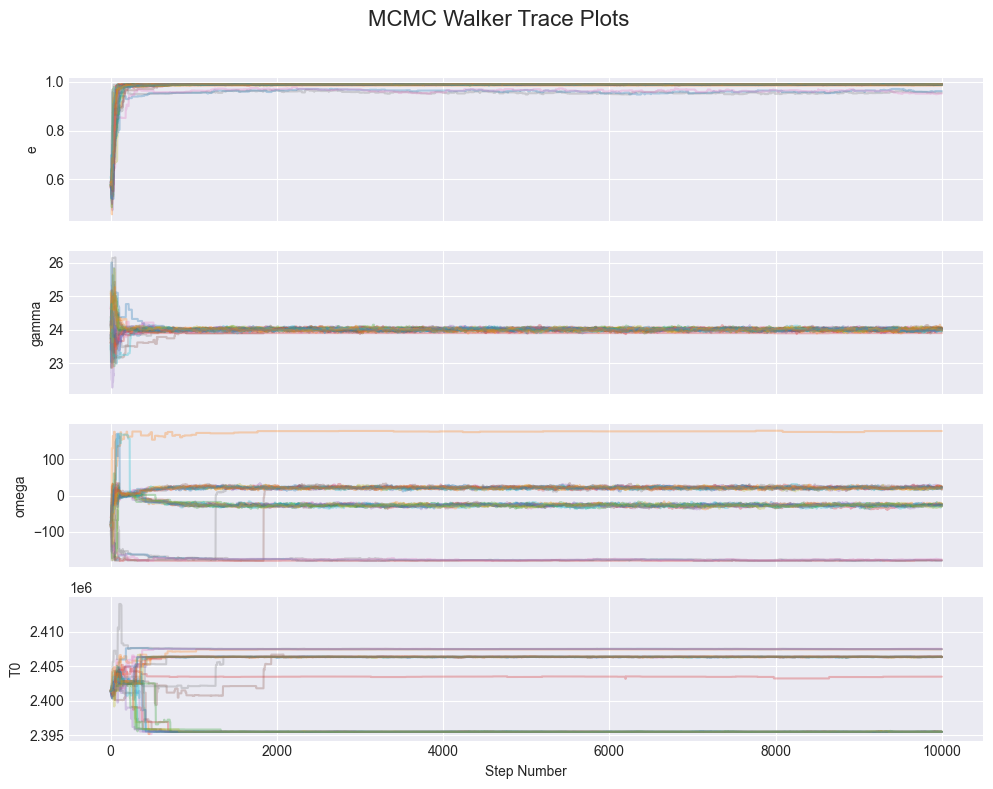

In [248]:
import matplotlib.pyplot as plt

# If sampler.chain is (nwalkers, nsteps, ndim)
samples = sampler.get_chain()  # shape: (nsteps, nwalkers, ndim)

param_names = ["e", "gamma", "omega", "T0"]  # adjust if using different parameters
nparams = samples.shape[2]
nwalkers = samples.shape[1]

fig, axes = plt.subplots(nparams, figsize=(10, 8), sharex=True)

for i in range(nparams):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(samples[:, walker, i], alpha=0.3)
    ax.set_ylabel(param_names[i])
    ax.grid(True)

axes[-1].set_xlabel("Step Number")
plt.suptitle("MCMC Walker Trace Plots", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [249]:
import numpy as np

samples = sampler.get_chain(discard=1000, thin=15, flat=True)  # Adjust burn-in and thinning as needed

param_names = ["e", "gamma", "omega", "T0"]

for i, name in enumerate(param_names):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{name} = {mcmc[1]:.5f} (+{q[1]:.5f}, -{q[0]:.5f})")


e = 0.98929 (+0.00054, -0.00178)
gamma = 24.01490 (+0.03488, -0.03521)
omega = -22.60477 (+46.02576, -8.54065)
T0 = 2406346.33999 (+45.41979, -10867.05060)


Running MCMC...


100%|████████████████████████████████████| 50000/50000 [01:26<00:00, 576.64it/s]


e = 0.57193 (+0.00524, -0.00530)
gamma = 23.95903 (+0.03137, -0.03164)
omega = -79.15008 (+0.94771, -0.94800)
T0 = 2394514.82630 (+17.84291, -17.63117)


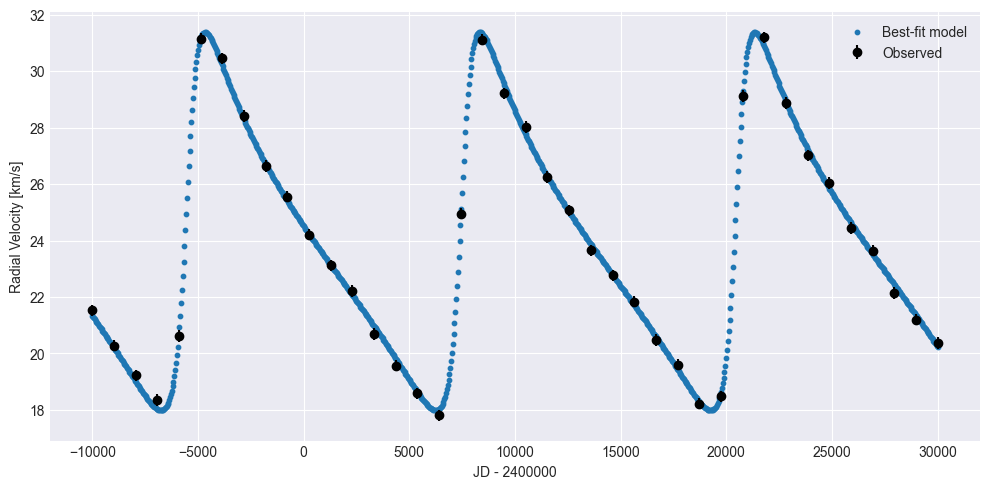

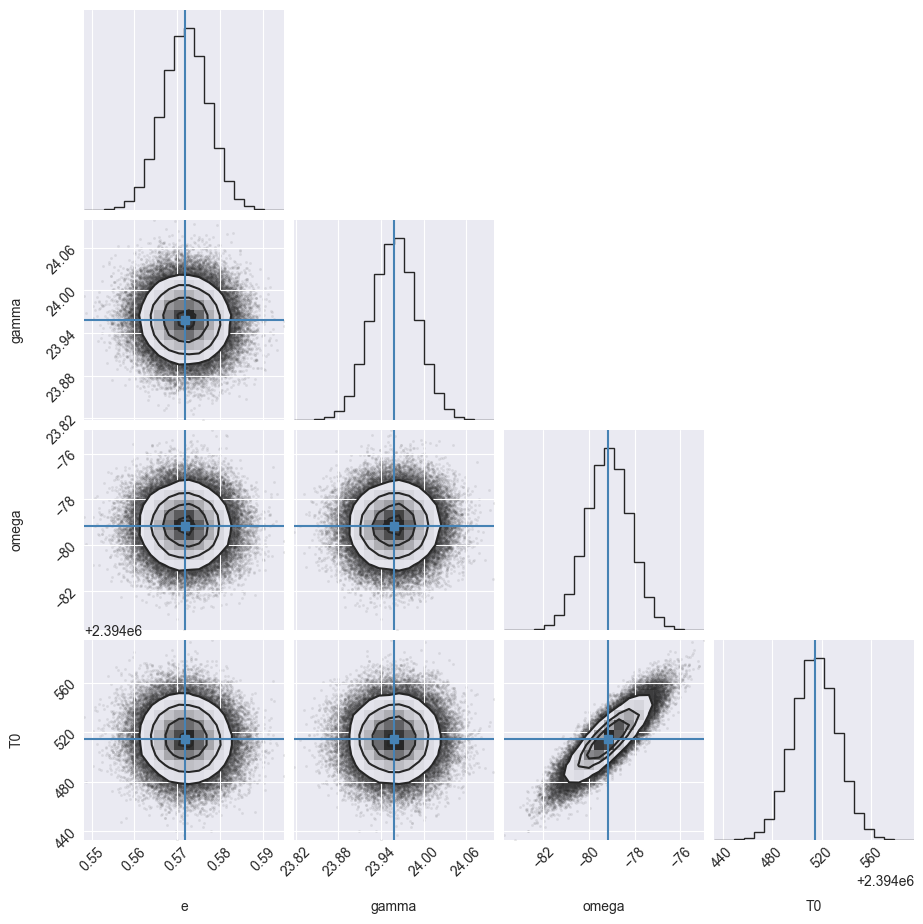

In [257]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

# === Kepler Solver ===
def solve_kepler(M, e, tol=1e-10, max_iter=100):
    M = np.mod(M, 2 * np.pi)
    E = np.where(e < 0.8, M, np.pi * np.ones_like(M))  # Good initial guess

    for i in range(max_iter):
        f = E - e * np.sin(E) - M
        f_prime = 1 - e * np.cos(E)
        delta = f / f_prime
        E -= delta
        if np.all(np.abs(delta) < tol):
            break
    else:
        raise RuntimeError("Kepler solver failed to converge.")
    return E

# === Keplerian Model ===
def keplerian_model(t, P, K, e, gamma, omega_deg, T0):
    omega = np.radians(omega_deg)
    M = 2 * np.pi * (t - T0) / P
    E = solve_kepler(M, e)
    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                        np.sqrt(1 - e) * np.cos(E / 2))
    rv = gamma + K * (np.cos(omega + nu) + e * np.cos(omega))
    return rv

# === Simulated Data ===
np.random.seed(42)
t = np.linspace(2390000, 2430000, 40)
P = 13000
K = 6.7
true_params = [0.58, 24.0, -80, 2394500.4]
rv_true = keplerian_model(t, P, K, *true_params)
rv_err = np.full_like(rv_true, 0.2)
rv_obs = rv_true + np.random.normal(0, rv_err)

# === Priors ===
def log_prior(theta):
    e, gamma, omega, T0 = theta
    if not (0.1 < e < 0.99):
        return -np.inf
    if not (0 <= gamma <= 40):
        return -np.inf
    if not (-180 <= omega <= 180):
        return -np.inf
    if not (2000000 <= T0 <= 2800000):
        return -np.inf
    return 0.0

# === Likelihood ===
def log_likelihood(theta, t, rv_obs, rv_err):
    e, gamma, omega, T0 = theta
    model = keplerian_model(t, P, K, e, gamma, omega, T0)
    return -0.5 * np.sum(((rv_obs - model) / rv_err) ** 2 + np.log(2 * np.pi * rv_err**2))

def log_probability(theta, t, rv_obs, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, rv_obs, rv_err)

# === MCMC Setup ===
ndim = 4
nwalkers = 32
initial = np.array([0.58, 24.0, -80, 2394500.4])
spread = [0.005, 0.5, 2.0, 10.0]
pos = initial + spread * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, rv_obs, rv_err))
print("Running MCMC...")
sampler.run_mcmc(pos, 50000, progress=True)

# === Analyze Samples ===
samples = sampler.get_chain(discard=10000, thin=15, flat=True)
labels = ['e', 'gamma', 'omega', 'T0']
for i, name in enumerate(labels):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{name} = {mcmc[1]:.5f} (+{q[1]:.5f}, -{q[0]:.5f})")

# === RV Curve ===
best_fit = np.median(samples, axis=0)
t_fine = np.linspace(min(t), max(t), 1000)
rv_model = keplerian_model(t_fine, P, K, *best_fit)

plt.figure(figsize=(10, 5))
plt.errorbar(t - 2.4e6, rv_obs, yerr=rv_err, fmt='o', label='Observed', color='black')
plt.scatter(t_fine - 2.4e6, rv_model, label='Best-fit model', color='tab:blue', s=10)
plt.xlabel("JD - 2400000")
plt.ylabel("Radial Velocity [km/s]")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# === Optional Corner Plot ===
try:
    import corner
    fig = corner.corner(samples, labels=labels, truths=best_fit)
    plt.show()
except ImportError:
    print("Install `corner` with: pip install corner")


In [258]:
# === Report Best-Fit Values with Uncertainties ===
labels = ['e', 'gamma', 'omega', 'T0']
samples = sampler.get_chain(discard=2000, thin=15, flat=True)

print("Best-fit parameters (with 1σ uncertainties):")
for i, label in enumerate(labels):
    median = np.percentile(samples[:, i], 50)
    lower = np.percentile(samples[:, i], 16)
    upper = np.percentile(samples[:, i], 84)
    print(f"{label:>6} = {median:.6f} (+{upper - median:.6f}, -{median - lower:.6f})")


Best-fit parameters (with 1σ uncertainties):
     e = 0.571938 (+0.005256, -0.005310)
 gamma = 23.958943 (+0.031511, -0.031454)
 omega = -79.153546 (+0.954213, -0.943970)
    T0 = 2394514.874676 (+17.854195, -17.636035)


In [259]:
def chi_squared(observed, model, errors):
    """Compute chi-squared statistic."""
    return np.sum(((observed - model) / errors) ** 2)

# === Compute best-fit model using median parameters ===
best_fit = np.median(samples, axis=0)
rv_model_best = keplerian_model(t, P, K, *best_fit)

# === Compute chi-squared and reduced chi-squared ===
chi2 = chi_squared(rv_obs, rv_model_best, rv_err)
dof = len(rv_obs) - len(best_fit)  # degrees of freedom: N_data - N_params
reduced_chi2 = chi2 / dof

print(f"Chi-squared: {chi2:.2f}")
print(f"Reduced Chi-squared (χ²/DOF): {reduced_chi2:.2f}")


Chi-squared: 32.34
Reduced Chi-squared (χ²/DOF): 0.90


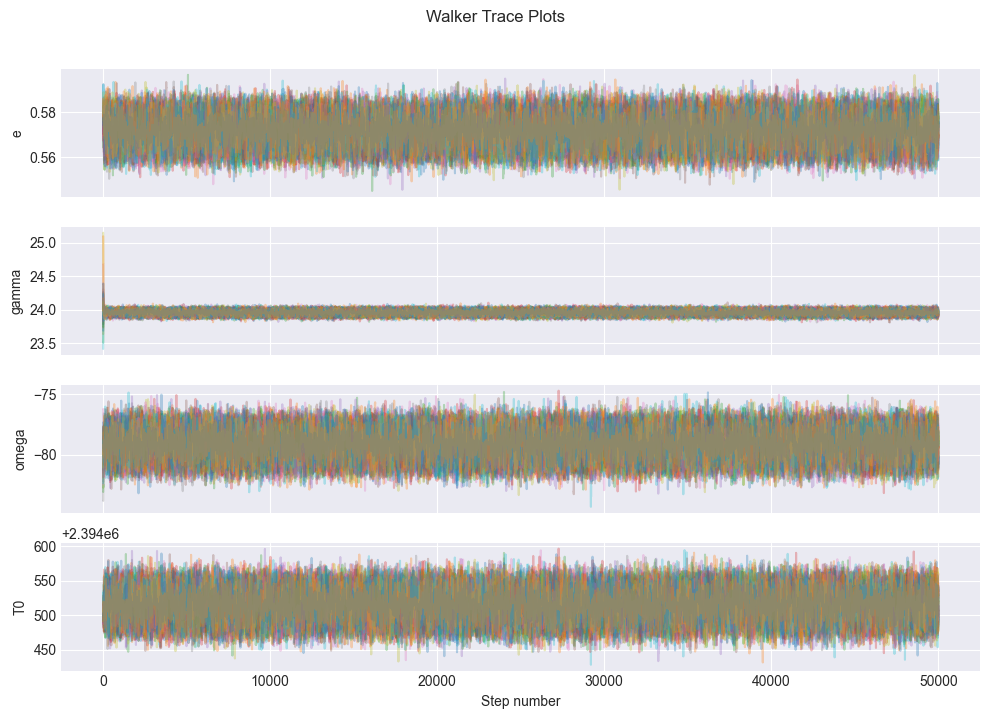

In [260]:
import matplotlib.pyplot as plt

# Get the full MCMC chain (shape: nsteps, nwalkers, ndim)
chain = sampler.get_chain()

labels = ['e', 'gamma', 'omega', 'T0']
nsteps, nwalkers, ndim = chain.shape

fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(chain[:, walker, i], alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.grid(True)
axes[-1].set_xlabel('Step number')
plt.suptitle("Walker Trace Plots", y=1.02)
plt.tight_layout()
plt.show()
